## Import - This notebook is for data analysis and visulization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
pr = "5"

In [6]:
 # path of results files
coverTable_benchmark = '../result/PR{} Testing/pr{}_cover_benchmark.npy'.format(pr, pr)
# coverTable_benchmark = '../result/cover_0_step20.npy'
coverTable1 = '../result/PR{} Testing/pr{}_cover_0_step20.npy'.format(pr, pr)
coverTable2 = '../result/PR{} Testing/pr{}_cover_100_step20.npy'.format(pr, pr)
coverTable3 = '../result/PR{} Testing/pr{}_cover_0_step20_deroute4.npy'.format(pr, pr)
coverTable4 = '../result/PR{} Testing/pr{}_cover_100_step20_deroute4.npy'.format(pr, pr)

# coverTable3 = '../result/{}/{}_cover_300_step20.npy'.format(pr, pr)
# coverTable4 = '../result/{}/{}_cover_500_step20.npy'.format(pr, pr)
coverTable5 = '../result/PR{} Testing/pr{}_cover_1000_step20.npy'.format(pr, pr)
coverTable6 = '../result/PR{} Testing/pr{}_cover_2000_step20.npy'.format(pr, pr)
lb_list = ['benchmark', '1:0', '1:100', '1:300(0+4)', '1:500(100+4)', '1:1000', '1:2000']
# lb_list = ['benchmark', '1:0', '1:300(20)', '1:500(40)']

In [7]:
# load cover table
cover_ben = np.load(coverTable_benchmark)
cover_1 = np.load(coverTable1)
cover_2 = np.load(coverTable2)
cover_3 = np.load(coverTable3)
cover_4 = np.load(coverTable4)
cover_5 = np.load(coverTable5)
cover_6 = np.load(coverTable6)

### 1. Link Cover Rate

In [8]:
# draw space time table
def drawTimeSpace(table):
    idx  = np.arange(0, 5000, 1)
    linkTime_table = np.sum(table, axis=2)
    del table
    linkTime_cover = np.where(linkTime_table[:, idx]>0, 1, 0)
    figs,axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(18, 1))
    axs[0].imshow(linkTime_table[:, idx], cmap='viridis', interpolation='none')
    axs[1].imshow(linkTime_cover, cmap='viridis', interpolation='none')
    print('cover rate is:', np.sum(linkTime_cover)/linkTime_cover.size)

    return linkTime_cover

cover rate is: 0.37506666666666666


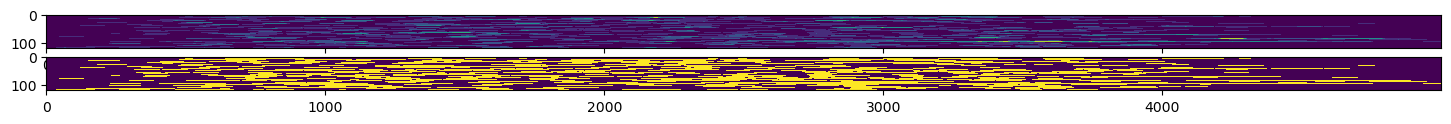

In [9]:
LT_ben = drawTimeSpace(cover_ben)

cover rate is: 0.48677166666666666


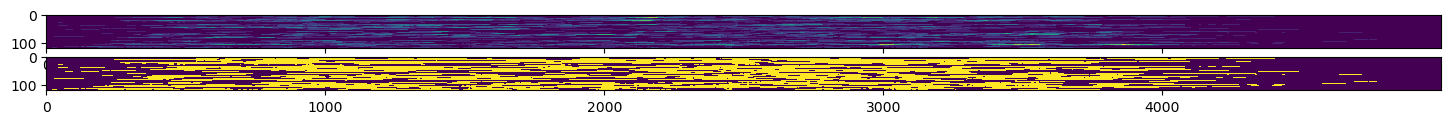

In [10]:
LT_1 = drawTimeSpace(cover_1)

cover rate is: 0.5189983333333333


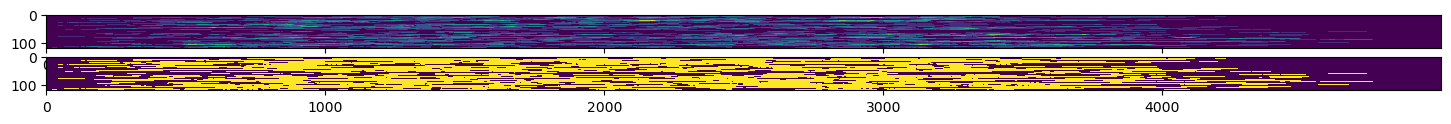

In [11]:
LT_2 = drawTimeSpace(cover_2)

cover rate is: 0.47983166666666666


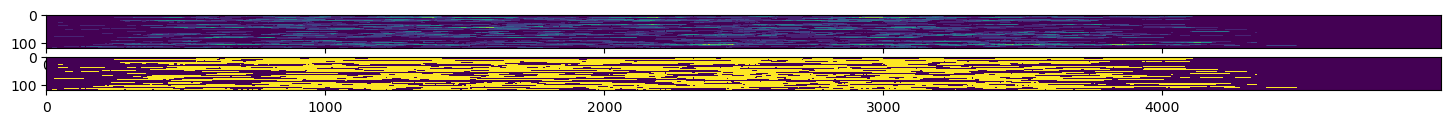

In [12]:
LT_3 = drawTimeSpace(cover_3)

cover rate is: 0.5225716666666667


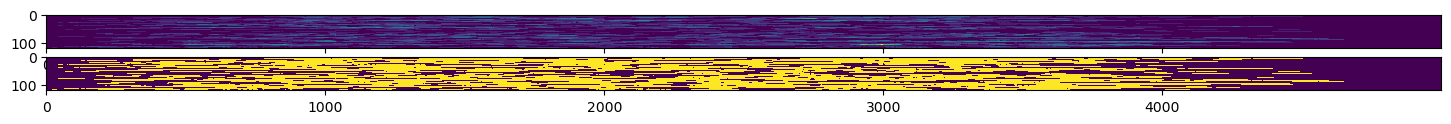

In [13]:
LT_4 = drawTimeSpace(cover_4)

cover rate is: 0.6879416666666667


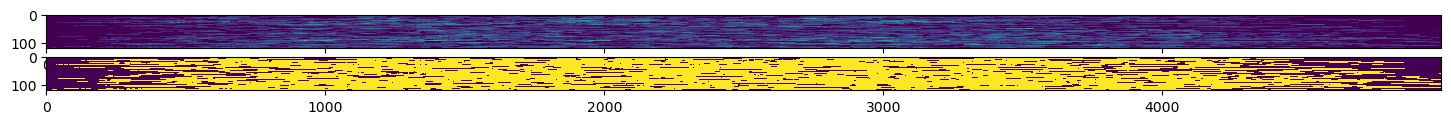

In [14]:
LT_5 = drawTimeSpace(cover_5)

cover rate is: 0.7175133333333333


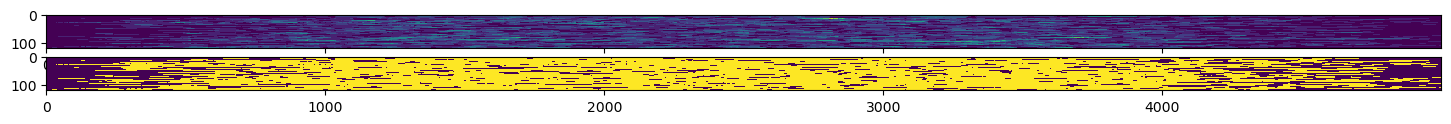

In [15]:
LT_6 = drawTimeSpace(cover_6)

### 2. Vehicle Travel Time

In [16]:
# cover_table = [link, time, veh]
def getTravelTime(table, max_veh_num):
    idx  = np.arange(0, 6000, 1)
    veh_time_table =np.sum(table, axis=0)>0  # [time, veh]
    travel_table = np.sum(veh_time_table, axis=0)
    return travel_table[:max_veh_num]


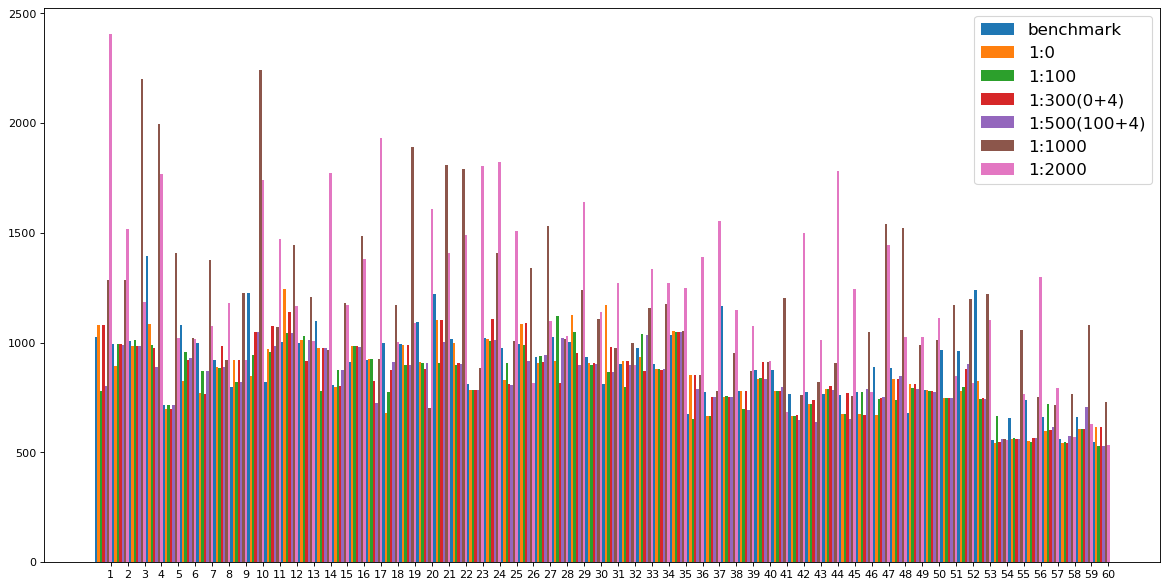

In [17]:
max_veh = 60
# getTravelTime(cover_ben, max_veh),
travelTime_list = [getTravelTime(cover_ben, max_veh),
                   getTravelTime(cover_1, max_veh), 
                   getTravelTime(cover_2, max_veh),
                   getTravelTime(cover_3, max_veh),
                   getTravelTime(cover_4, max_veh),
                   getTravelTime(cover_5, max_veh),
                   getTravelTime(cover_6, max_veh),]
veh_list = ['{}'.format(str(i+1)) for i in range(max_veh)]
total_width, n = 1, len(travelTime_list)
width = total_width/n
x = np.arange(len(veh_list))
plt.figure(figsize=(18, 9), dpi=80)

for k in range(len(travelTime_list)):
    xx = x + np.ones(x.shape)*k*width
    plt.bar(xx, travelTime_list[k], width=width, label = str(k), tick_label = veh_list)
plt.legend(lb_list, fontsize=15)
plt.show()

[ 902.85        846.61666667  830.76666667  850.18333333  833.28333333
 1161.41666667 1214.03333333] [0.37506667 0.48677167 0.51899833 0.47983167 0.52257167 0.68794167
 0.71751333]


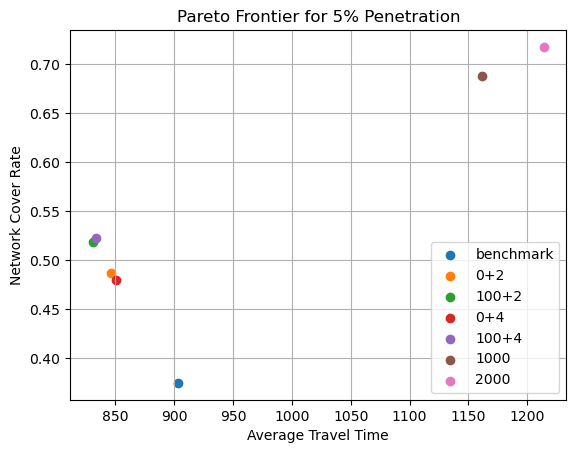

In [22]:
tt_mean = np.mean(np.array(travelTime_list),axis=1)  # travel time

# np.sum(LT_ben)/LT_ben.size,
cover_mean = np.array([np.sum(LT_ben)/LT_ben.size,
                       np.sum(LT_1)/LT_1.size,
                       np.sum(LT_2)/LT_2.size, 
                       np.sum(LT_3)/LT_3.size,
                       np.sum(LT_4)/LT_4.size,
                       np.sum(LT_5)/LT_5.size,
                       np.sum(LT_6)/LT_6.size])
alpha_list = [0, 100, 300, 500, 1000, 2000]
deroute_list = ['benchmark', '0+2', '100+2', '0+4', '100+4', '1000', '2000']
for i in range(tt_mean.shape[0]):
    plt.scatter(tt_mean[i], cover_mean[i], label = str(deroute_list[i]))
#     plt.scatter(tt_mean[i], cover_mean[i], label = '$\u03B1_{2}$'+"="+ str(alpha_list[i]))
plt.legend(loc=4)
plt.xlabel('Average Travel Time')
plt.ylabel('Network Cover Rate')
plt.title('Pareto Frontier for 5% Penetration')
plt.grid()
print(tt_mean, cover_mean)

### 3. Network Visulize

In [23]:
import networkx as nx
import sumolib

#### 3.1 load network

In [95]:
def getDis(crd1, crd2):
    return np.sqrt((crd1[0] - crd2[0]) ** 2 + (crd1[1] - crd2[1]) ** 2)

In [116]:
def netInit(X, Y, net_file='../src/sumo_cfg/toy_net/toy_net1.net.xml'):
    net = sumolib.net.readNet(net_file)
    G = nx.DiGraph()
    tmp_node = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    pos = {}
    for x in range(X):
        for y in range(Y):
            node_idx = tmp_node[x]+tmp_node[y]
            pos[node_idx] = net.getNode(node_idx).getCoord()
            G.add_node(node_idx, color='red', pos=net.getNode(node_idx).getCoord())
    
    for x in range(X):
        for y in range(Y):
            if x + 1 < X and y + 1 < Y:
                current = tmp_node[x] + tmp_node[y]
                current_right = tmp_node[x] + tmp_node[y + 1]
                current_down = tmp_node[x + 1] + tmp_node[y]
                dis1 = getDis(net.getNode(current).getCoord(), net.getNode(current_right).getCoord())
                dis2 = getDis(net.getNode(current).getCoord(), net.getNode(current_down).getCoord())
                G.add_weighted_edges_from([(current, current_right, dis1),
                                           (current_right, current, dis1),
                                           (current, current_down, dis2),
                                           (current_down, current, dis2)])
    
            elif y + 1 == Y and x + 1 < X:
                current = tmp_node[x] + tmp_node[y]
                current_down = tmp_node[x + 1] + tmp_node[y]
                dis2 = getDis(net.getNode(current).getCoord(), net.getNode(current_down).getCoord())
                G.add_weighted_edges_from([(current, current_down, dis2), (current_down, current, dis2)])
            elif x + 1 == X and y + 1 < Y:
                current = tmp_node[x] + tmp_node[y]
                current_right = tmp_node[x] + tmp_node[y + 1]
                dis1 = getDis(net.getNode(current).getCoord(), net.getNode(current_right).getCoord())
                G.add_weighted_edges_from([(current, current_right, dis1), (current_right, current, dis1)])
            elif x == y == X-1:
                break
    return G, pos

In [117]:
G, pos = netInit(6,6)

(('AA', 'AB'), ('AA', 'BA'), ('AB', 'AA'), ('AB', 'AC'), ('AB', 'BB'), ('AC', 'AB'), ('AC', 'AD'), ('AC', 'BC'), ('AD', 'AC'), ('AD', 'AE'), ('AD', 'BD'), ('AE', 'AD'), ('AE', 'AF'), ('AE', 'BE'), ('AF', 'AE'), ('AF', 'BF'), ('BA', 'AA'), ('BA', 'BB'), ('BA', 'CA'), ('BB', 'AB'), ('BB', 'BA'), ('BB', 'BC'), ('BB', 'CB'), ('BC', 'AC'), ('BC', 'BB'), ('BC', 'BD'), ('BC', 'CC'), ('BD', 'AD'), ('BD', 'BC'), ('BD', 'BE'), ('BD', 'CD'), ('BE', 'AE'), ('BE', 'BD'), ('BE', 'BF'), ('BE', 'CE'), ('BF', 'AF'), ('BF', 'BE'), ('BF', 'CF'), ('CA', 'BA'), ('CA', 'CB'), ('CA', 'DA'), ('CB', 'BB'), ('CB', 'CA'), ('CB', 'CC'), ('CB', 'DB'), ('CC', 'BC'), ('CC', 'CB'), ('CC', 'CD'), ('CC', 'DC'), ('CD', 'BD'), ('CD', 'CC'), ('CD', 'CE'), ('CD', 'DD'), ('CE', 'BE'), ('CE', 'CD'), ('CE', 'CF'), ('CE', 'DE'), ('CF', 'BF'), ('CF', 'CE'), ('CF', 'DF'), ('DA', 'CA'), ('DA', 'DB'), ('DA', 'EA'), ('DB', 'CB'), ('DB', 'DA'), ('DB', 'DC'), ('DB', 'EB'), ('DC', 'CC'), ('DC', 'DB'), ('DC', 'DD'), ('DC', 'EC'), ('DD'

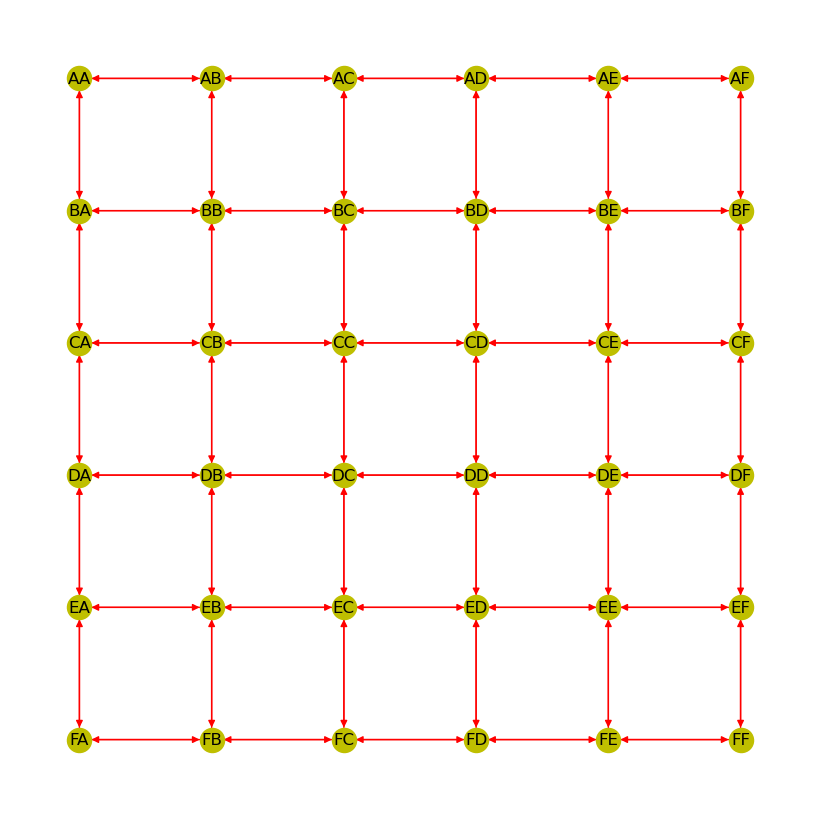

In [118]:
plt.figure(figsize=(8, 8))
edges,weights = zip(*nx.get_edge_attributes(G,'weight').items())
print(edges)

# pos = nx.layout(G)
# print(pos)
# print(edges)
# print(weights)

nx.draw(G, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='r', 
        width=1, edge_cmap=plt.cm.Blues)
plt.show()

# nx.draw(H, pos, with_labels = True, node_color='y', 
#         edgelist=edges, edge_color=weights, 
#         width=weights, edge_cmap=plt.cm.Blues)



### 3.2 visulize cover&TT

In [119]:
# def drawCoverNet(G, cover_table, net_file='../src/sumo_cfg/toy_net/toy_net1.net.xml'):
#     """
#     cover_table = [link, time, veh]
#     """
#     obs_table = np.where(np.sum(cover_table, axis=2)>0, 1, 0)
#     link_cover = np.sum(obs_table, axis=1)/obs_table.shape[1]
#     print(link_cover.shape)
#     net = sumolib.net.readNet(net_file)
# #     print(link_cover)
#     for i in range(cover_table.shape[0]):
#         if i <60: 
#             edge_id = 'E'+str(i+1)
#         else: 
#             edge_id = '-E'+str(i-59)
        
#         nextNodeID = net.getEdge(edge_id).getToNode().getID()
#         lastNodeID = net.getEdge(edge_id).getFromNode().getID()
#         G[lastNodeID][nextNodeID]['weight']=link_cover[i]
#     return G
        
            

In [171]:
def drawCoverNet(G, cover_table, net_file='../src/sumo_cfg/toy_net/toy_net1.net.xml'):
    obs_table = np.where(np.sum(cover_table, axis=2)>0, 1, 0)
    link_cover = np.sum(obs_table, axis=1)/obs_table.shape[1]
    net = sumolib.net.readNet(net_file)

    # Get node positions from SUMO net file
    pos = {}
    for node in net.getNodes():
        pos[node.getID()] = node.getCoord()
    
    for i in range(link_cover.shape[0]):
        if i < 60: 
            edge_id = 'E' + str(i + 1)
        else: 
            edge_id = '-E' + str(i - 59)
        
        nextNodeID = net.getEdge(edge_id).getToNode().getID()
        lastNodeID = net.getEdge(edge_id).getFromNode().getID()
        G[lastNodeID][nextNodeID]['weight'] = link_cover[i]

    plt.figure(figsize=(8, 8))
    edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())
    max_weight = max(weights)
    weights = [ 5 * w / max_weight for w in weights]  # Adjust the '5' for preferred max thickness

    count = 0
    for (src, dst, data) in G.edges(data=True):
#         print(data)
        weight = 3* data['weight']/max_weight
        
        color = 'red'
        
        x0, y0 = pos[src]
        x1, y1 = pos[dst]
#         print(src, dst)
        rad = 0.1  # Radius of curvature
        color = 'red' if src < dst else 'blue'  # Determines which way the arc curves
#         print (curvature,src, dst, weight)
        arrowprops=dict(arrowstyle='-|>',
                        color=color,
                        lw=weight,
                        connectionstyle=f"arc3,rad={rad}")
        plt.annotate("",
                     xy=(x1, y1),
                     xytext=(x0, y0),
                     arrowprops=arrowprops)

    nx.draw_networkx_nodes(G, pos, node_color='yellow')
    nx.draw_networkx_labels(G, pos)

    plt.axis('off')
    plt.show()


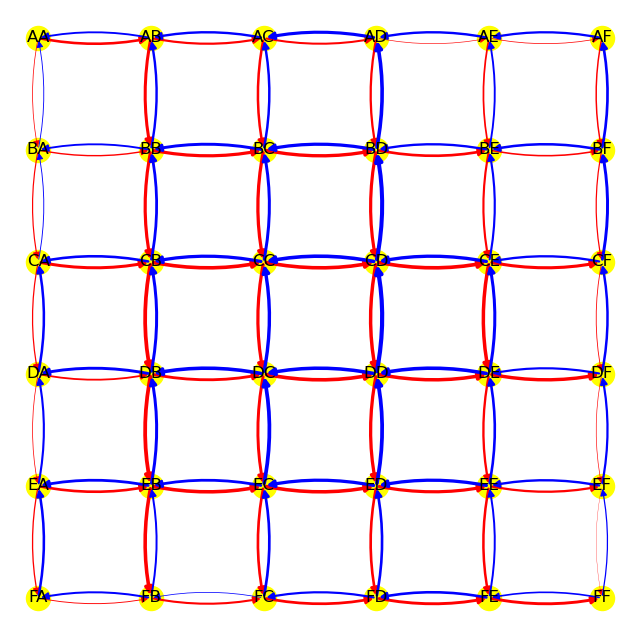

In [172]:
drawCoverNet(G, cover_ben)

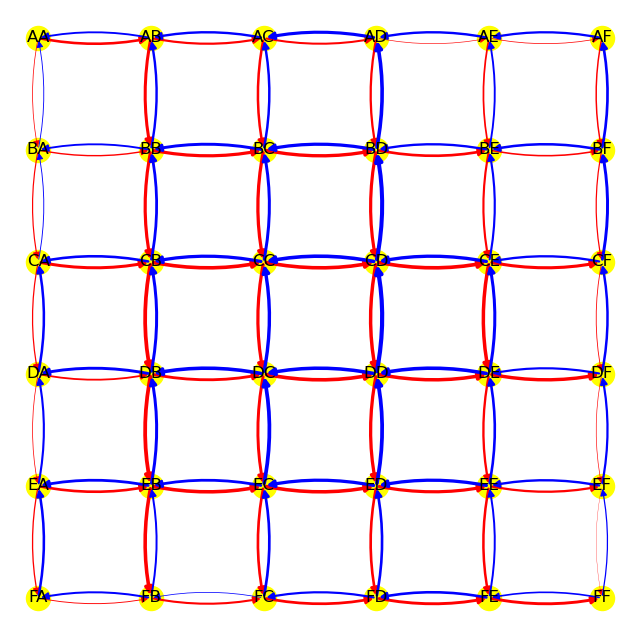

In [173]:
drawCoverNet(G, cover_1)

(120,)


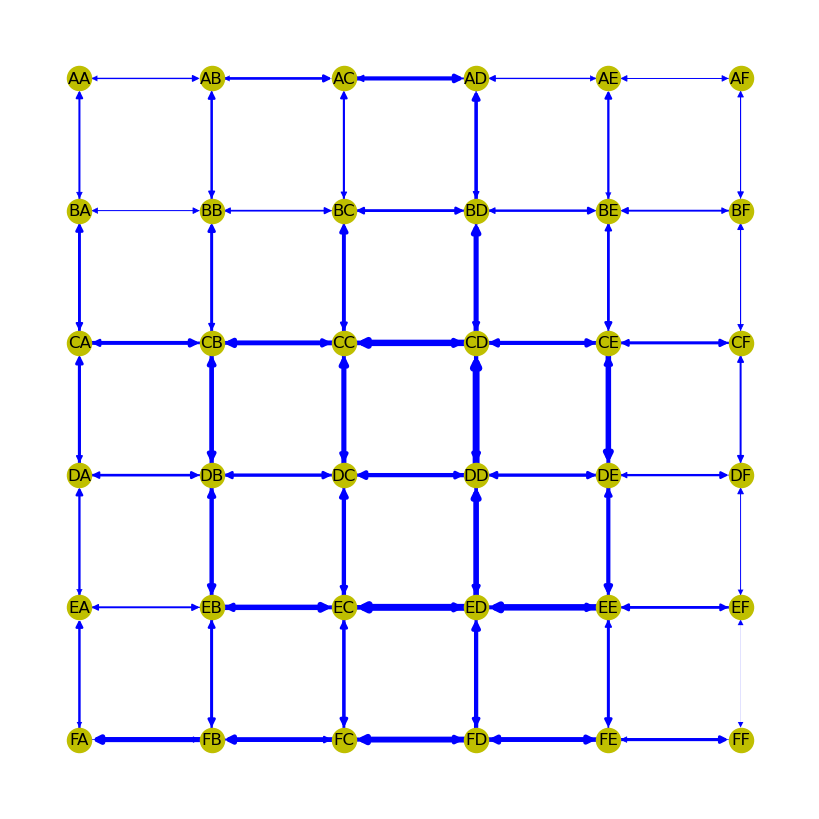

In [122]:
drawCoverNet(G, cover_2)

(120,)


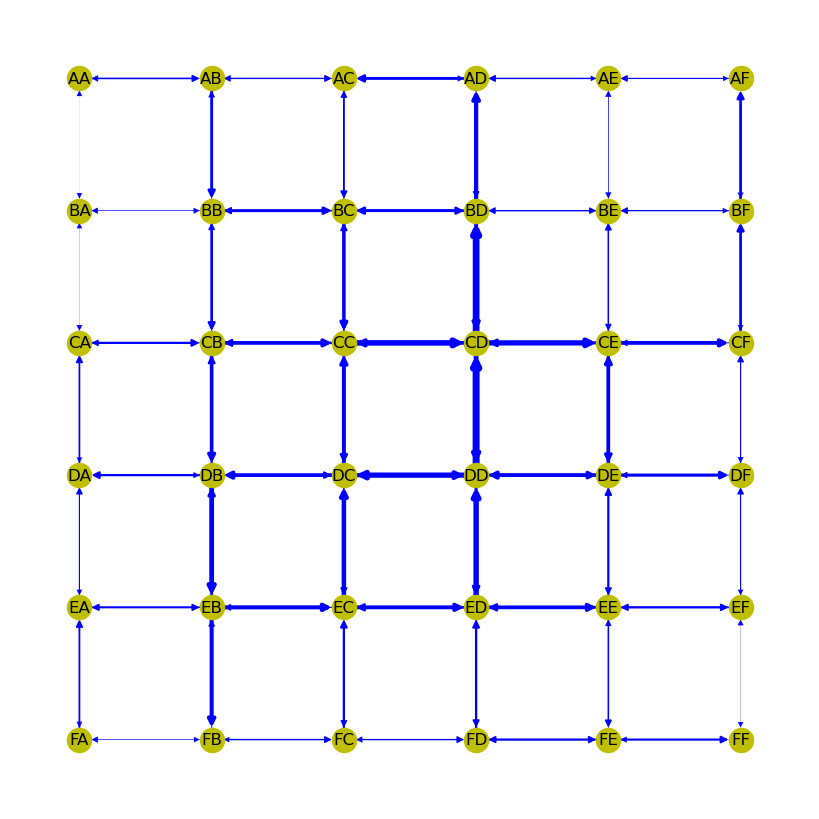

In [123]:
drawCoverNet(G, cover_3)

(120,)


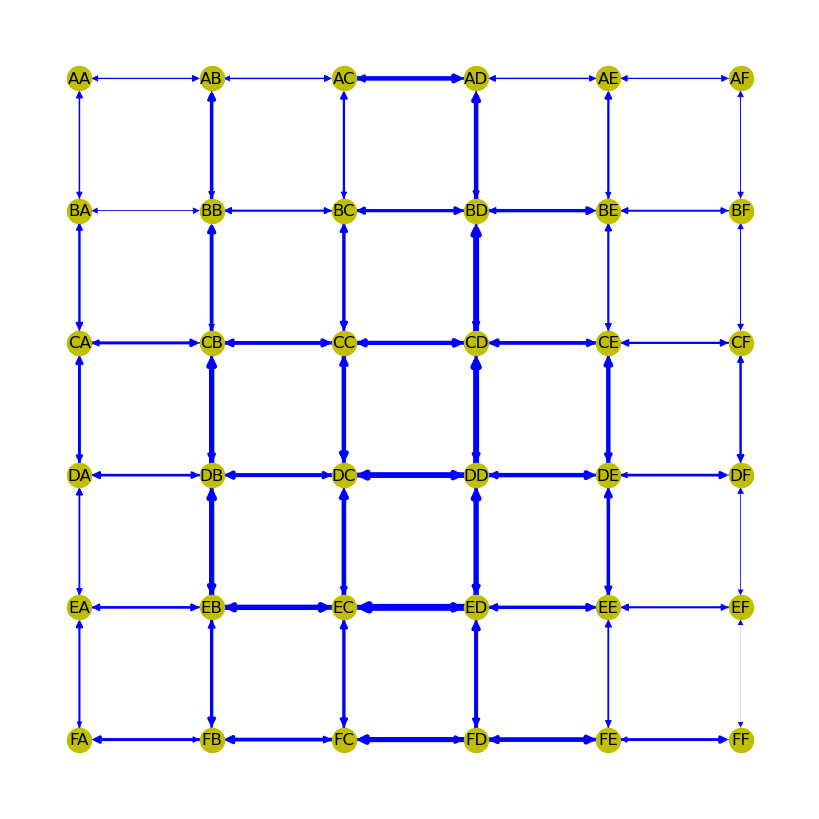

In [124]:
drawCoverNet(G, cover_4)

(120,)


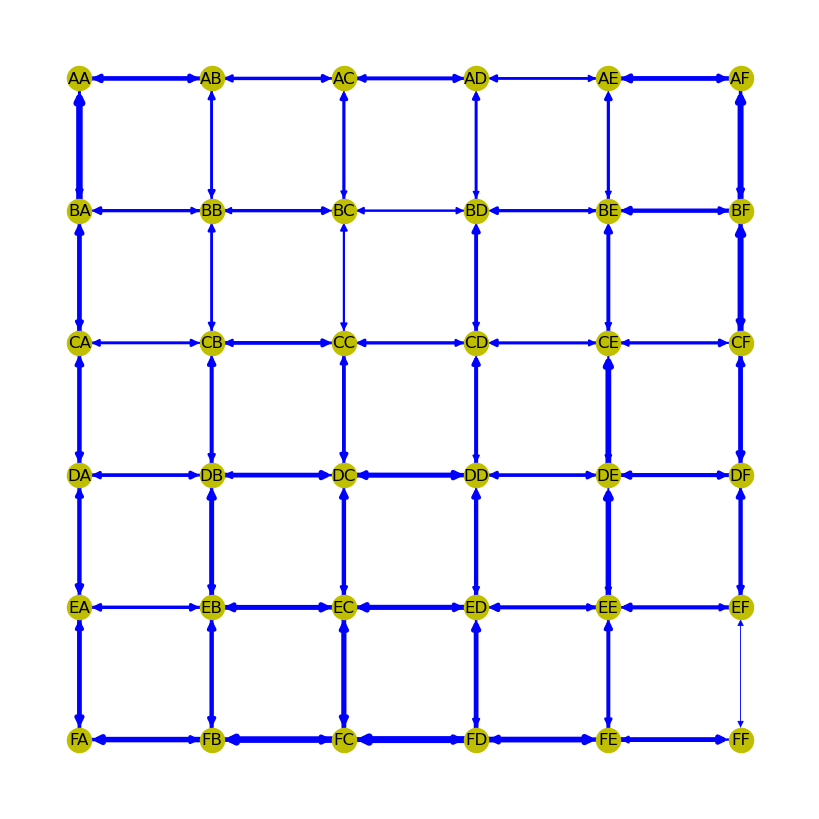

In [125]:
drawCoverNet(G, cover_5)

(120,)


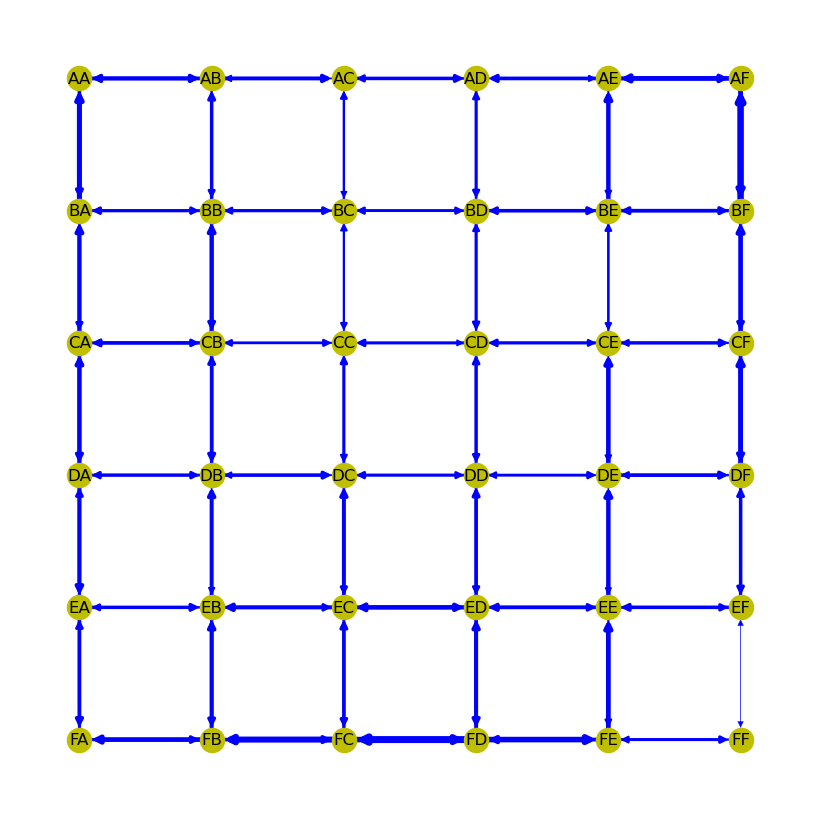

In [126]:
drawCoverNet(G, cover_6)

### 3.3 Draw Network volume

In [167]:
def drawVolumeNet(G, cover_table, net_file='../src/sumo_cfg/toy_net/toy_net1.net.xml'):
    volume_table = np.where(np.sum(cover_table, axis=1) > 0, 1, 0)
    link_volume = np.sum(volume_table, axis=1)
    net = sumolib.net.readNet(net_file)

    # Get node positions from SUMO net file
    pos = {}
    for node in net.getNodes():
        pos[node.getID()] = node.getCoord()
    
    for i in range(link_volume.shape[0]):
        if i < 60: 
            edge_id = 'E' + str(i + 1)
        else: 
            edge_id = '-E' + str(i - 59)
        
        nextNodeID = net.getEdge(edge_id).getToNode().getID()
        lastNodeID = net.getEdge(edge_id).getFromNode().getID()
        G[lastNodeID][nextNodeID]['weight'] = link_volume[i]

    plt.figure(figsize=(8, 8))
    edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())
    max_weight = max(weights)
    weights = [ 5 * w / max_weight for w in weights]  # Adjust the '5' for preferred max thickness

    count = 0
    for (src, dst, data) in G.edges(data=True):
#         print(data)
        weight = 3* data['weight']/max_weight
        
        color = 'red'
        
        x0, y0 = pos[src]
        x1, y1 = pos[dst]
#         print(src, dst)
        rad = 0.1  # Radius of curvature
        color = 'red' if src < dst else 'blue'  # Determines which way the arc curves
#         print (curvature,src, dst, weight)
        arrowprops=dict(arrowstyle='-|>',
                        color=color,
                        lw=weight,
                        connectionstyle=f"arc3,rad={rad}")
        plt.annotate("",
                     xy=(x1, y1),
                     xytext=(x0, y0),
                     arrowprops=arrowprops)

    nx.draw_networkx_nodes(G, pos, node_color='yellow')
    nx.draw_networkx_labels(G, pos)

    plt.axis('off')
    plt.show()


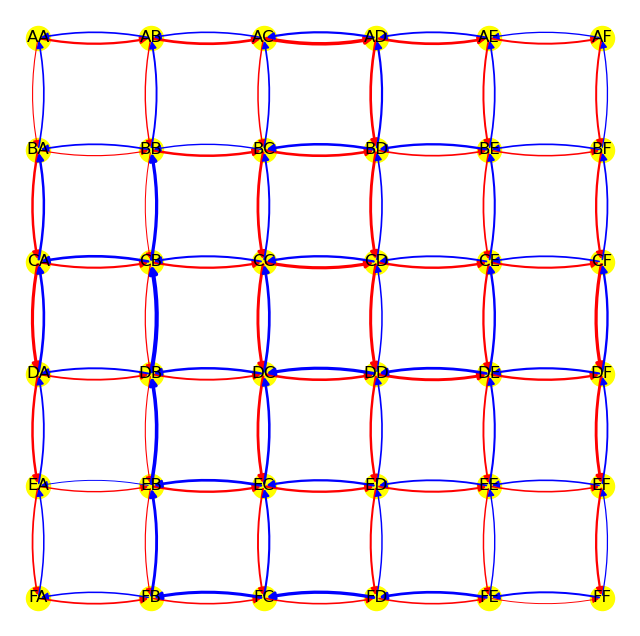

In [168]:
drawVolumeNet(G, cover_ben)

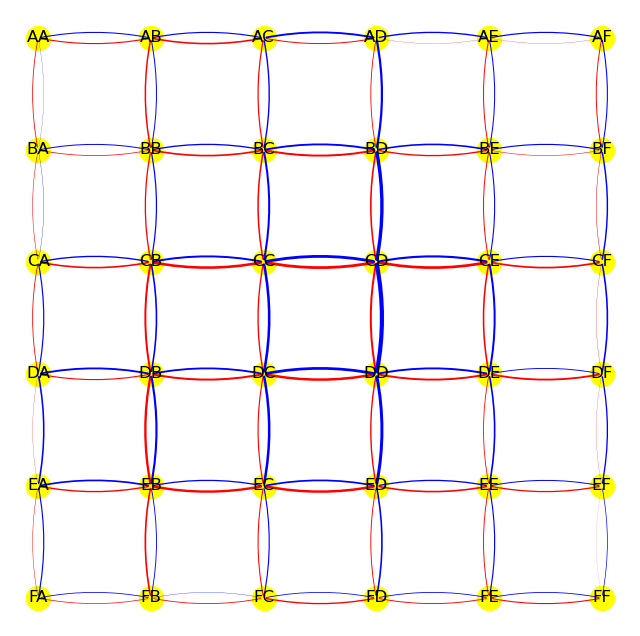

In [161]:
drawVolumeNet(G, cover_1)

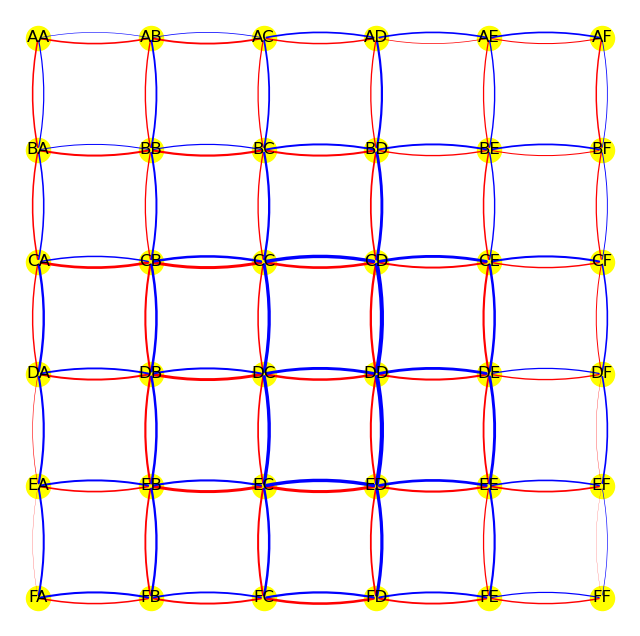

In [162]:
drawVolumeNet(G, cover_2)

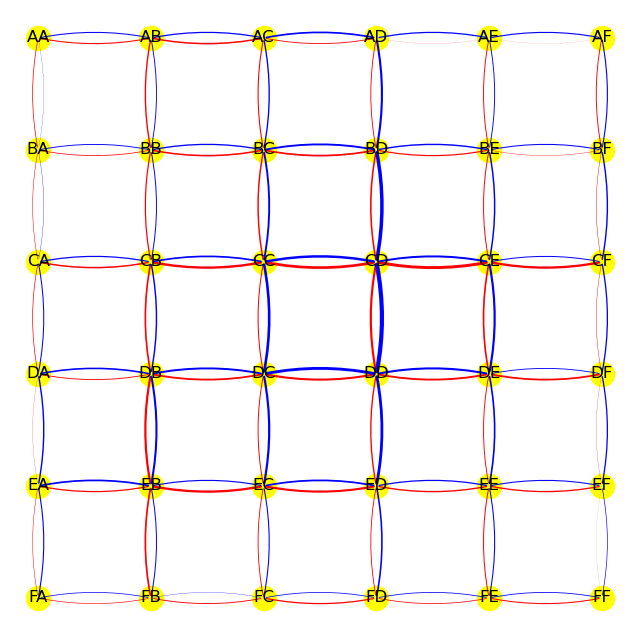

In [159]:
drawVolumeNet(G, cover_3)

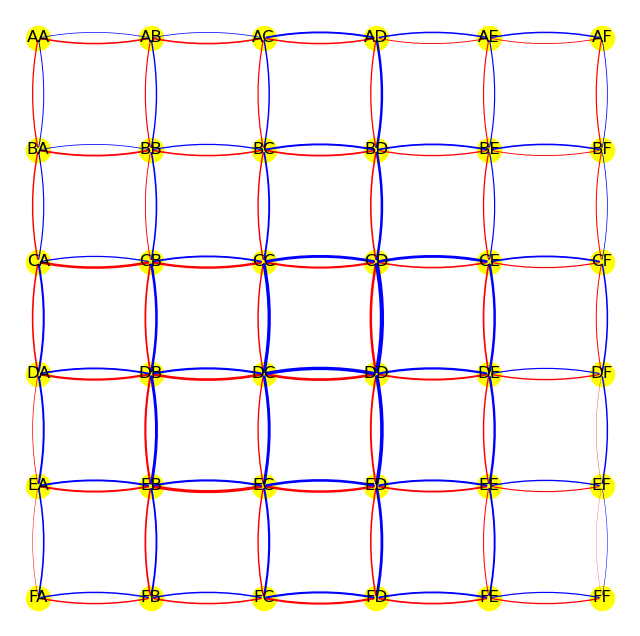

In [164]:
drawVolumeNet(G, cover_4)

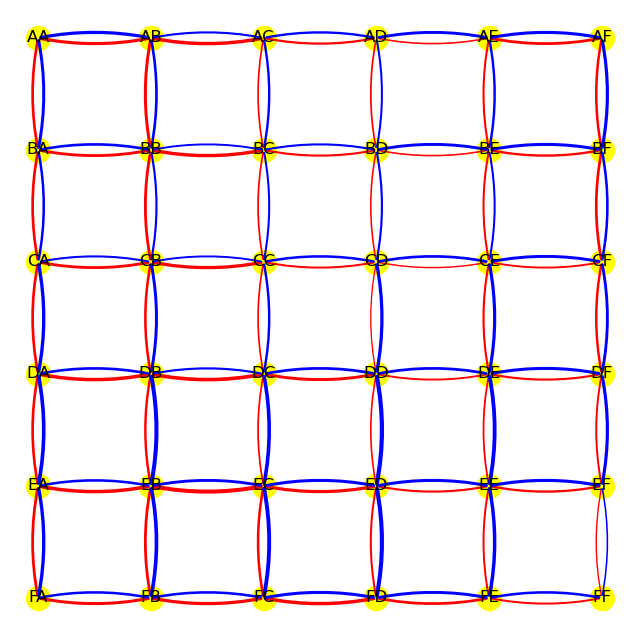

In [165]:
drawVolumeNet(G, cover_5)

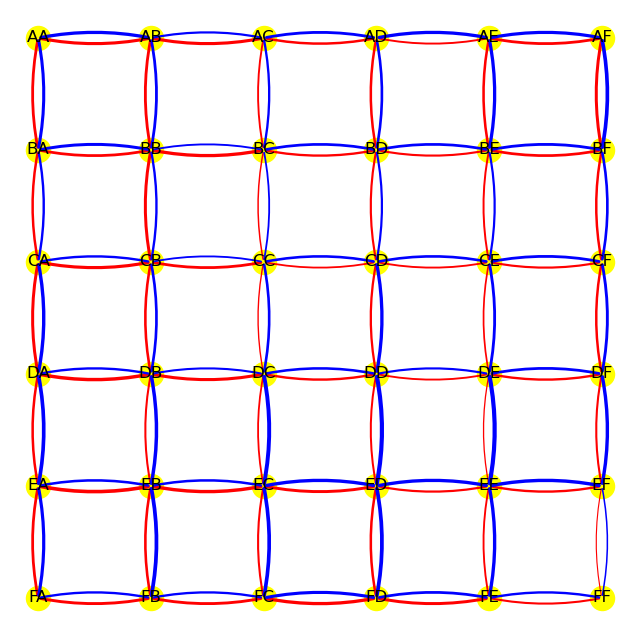

In [166]:
drawVolumeNet(G, cover_6)